# Observed SPHEREx: extend the SED
**Question:** what changes when we add measured infrared channels to the same SB2?

Allow **6 minutes**. We will inspect exposure quality, attach the real channel-binned
spectrum, and compare XP-only and XP+SPHEREx fits. This notebook runs independently.
Its default uses the included QR2 extraction for Gaia DR3 **858860697467058688**.
Live downloading additionally needs `sedkit[spherex]`, network access and several minutes
for the first isolated TallTable/SPExPI setup.

In [1]:
from pathlib import Path
import sys, json, csv
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

ROOT = Path(globals().get('__file__', Path.cwd())).resolve()
if ROOT.is_file():
    ROOT = ROOT.parent
while not (ROOT / 'src' / 'sedkit').is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / 'src' / 'sedkit').is_dir():
    raise RuntimeError('Open this notebook from the sedkit checkout.')
sys.path.insert(0, str(ROOT / 'src'))
from sedkit import SED, StellarModel, download, fit, plot
from sedkit.plot import PAPER_STYLE, BINARY, SINGLE

OUT = ROOT / 'examples' / 'group_meeting' / 'outputs'
OUT.mkdir(parents=True, exist_ok=True)
model = StellarModel()

## 1. Inspect the extraction before fitting
The download route uses XphereX aperture extraction with TallTable and SPExPI.
Incomplete or flagged apertures are retained in the exposure table, but excluded
from the binned spectrum. Missing channels remain missing.

In [2]:
from sedkit import download_spherex, load_spherex
SOURCE_ID = '858860697467058688'
base = SED.load(ROOT / 'examples' / 'sb2_20260927' / (SOURCE_ID + '.npz'))
products = ROOT / 'examples' / 'spherex_20260927'
exposures = np.genfromtxt(products / 'aperture_exposures.csv', delimiter=',', names=True,
                         dtype=None, encoding='utf-8')
valid = np.asarray(exposures['valid'], str) == 'True'
print(f'Measured exposures: {len(exposures)}; complete, unflagged: {valid.sum()}')
print('Original exposure fluxes and errors are preserved in the CSV.')

Measured exposures: 307; complete, unflagged: 80
Original exposure fluxes and errors are preserved in the CSV.


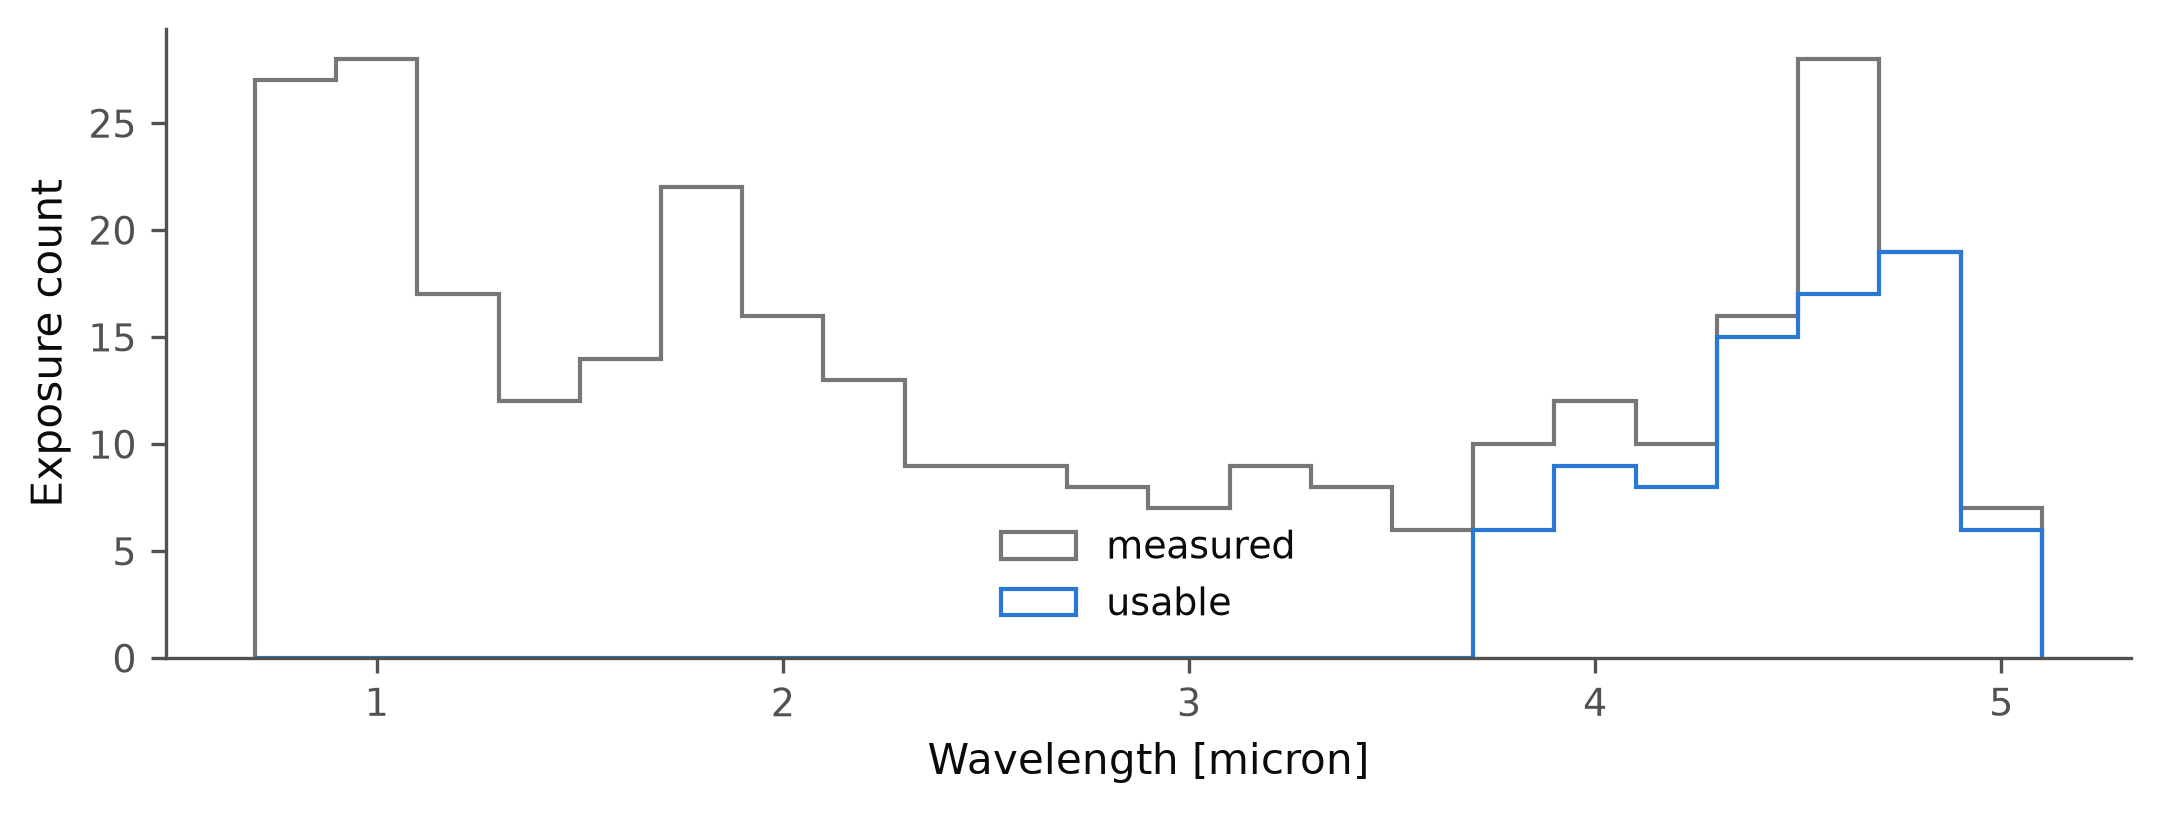

In [3]:
with plt.rc_context(PAPER_STYLE):
    fig, ax = plt.subplots(figsize=(7.087, 2.6), layout='constrained')
    bins = np.linspace(.7, 5.1, 23)
    ax.hist(exposures['wavelength_um'], bins=bins, histtype='step', color='#777777', label='measured')
    ax.hist(exposures['wavelength_um'][valid], bins=bins, histtype='step', color=BINARY, label='usable')
    ax.set(xlabel='Wavelength [micron]', ylabel='Exposure count')
    ax.legend()
    for extension in ('png', 'pdf'):
        fig.savefig(OUT / ('02_exposure_quality.' + extension), dpi=300, bbox_inches='tight')
    plt.close(fig)
display(Image(filename=str(OUT / '02_exposure_quality.png')))

## 2. Attach the observed spectrum
The API supports either a live pixel download or an existing XphereX CSV.
Import converts Jy to physical F_lambda units at the measured distance, with no
interpolation, normalization, zero-point correction or error rescaling.

In [4]:
LIVE_DOWNLOAD = False
combined = (download_spherex(base, cache_dir=OUT / 'cache') if LIVE_DOWNLOAD
            else load_spherex(base, products / 'aperture_spectrum.csv', method='aperture'))
print(f'Usable SPHEREx channels: {combined.mask[66:].sum()} / 102')
print(f'Combined fitted channels: {combined.fit_mask().sum()}')
np.testing.assert_array_equal(combined.flux[:66], base.flux[:66])
np.testing.assert_array_equal(combined.error[:66], base.error[:66])

Usable SPHEREx channels: 34 / 102
Combined fitted channels: 98


## 3. Fit the same star with and without SPHEREx
Age and metallicity remain free, and both fits retain the absolute observed scale.
Objectives on different channel sets are not comparable as a binary evidence ratio;
we compare their fitted parameters and their own residuals.

In [5]:
xp_result = fit(base, kind='binary', model=model, age_gyr=None, feh=None)
sph_result = fit(combined, model=model, age_gyr=None, feh=None)
for label, r in [('XP + JHKs', xp_result), ('XP + JHKs + SPHEREx', sph_result['binary'])]:
    print(f"{label}: q={r['q']:.4f}, M1={r['m1']:.3f}, age={r['age_gyr']:.2f} Gyr, "
          f"[M/H]={r['feh']:.2f}, chi2/N={r['chi2']/r['n_fit']:.2f}, bounds={r['at_bounds']}")
print('Published RV comparison: q = 0.8679')

XP + JHKs: q=0.8553, M1=0.862, age=10.00 Gyr, [M/H]=0.08, chi2/N=1.19, bounds=['ln_age']
XP + JHKs + SPHEREx: q=0.8285, M1=0.871, age=10.00 Gyr, [M/H]=0.09, chi2/N=1.11, bounds=['ln_age']
Published RV comparison: q = 0.8679


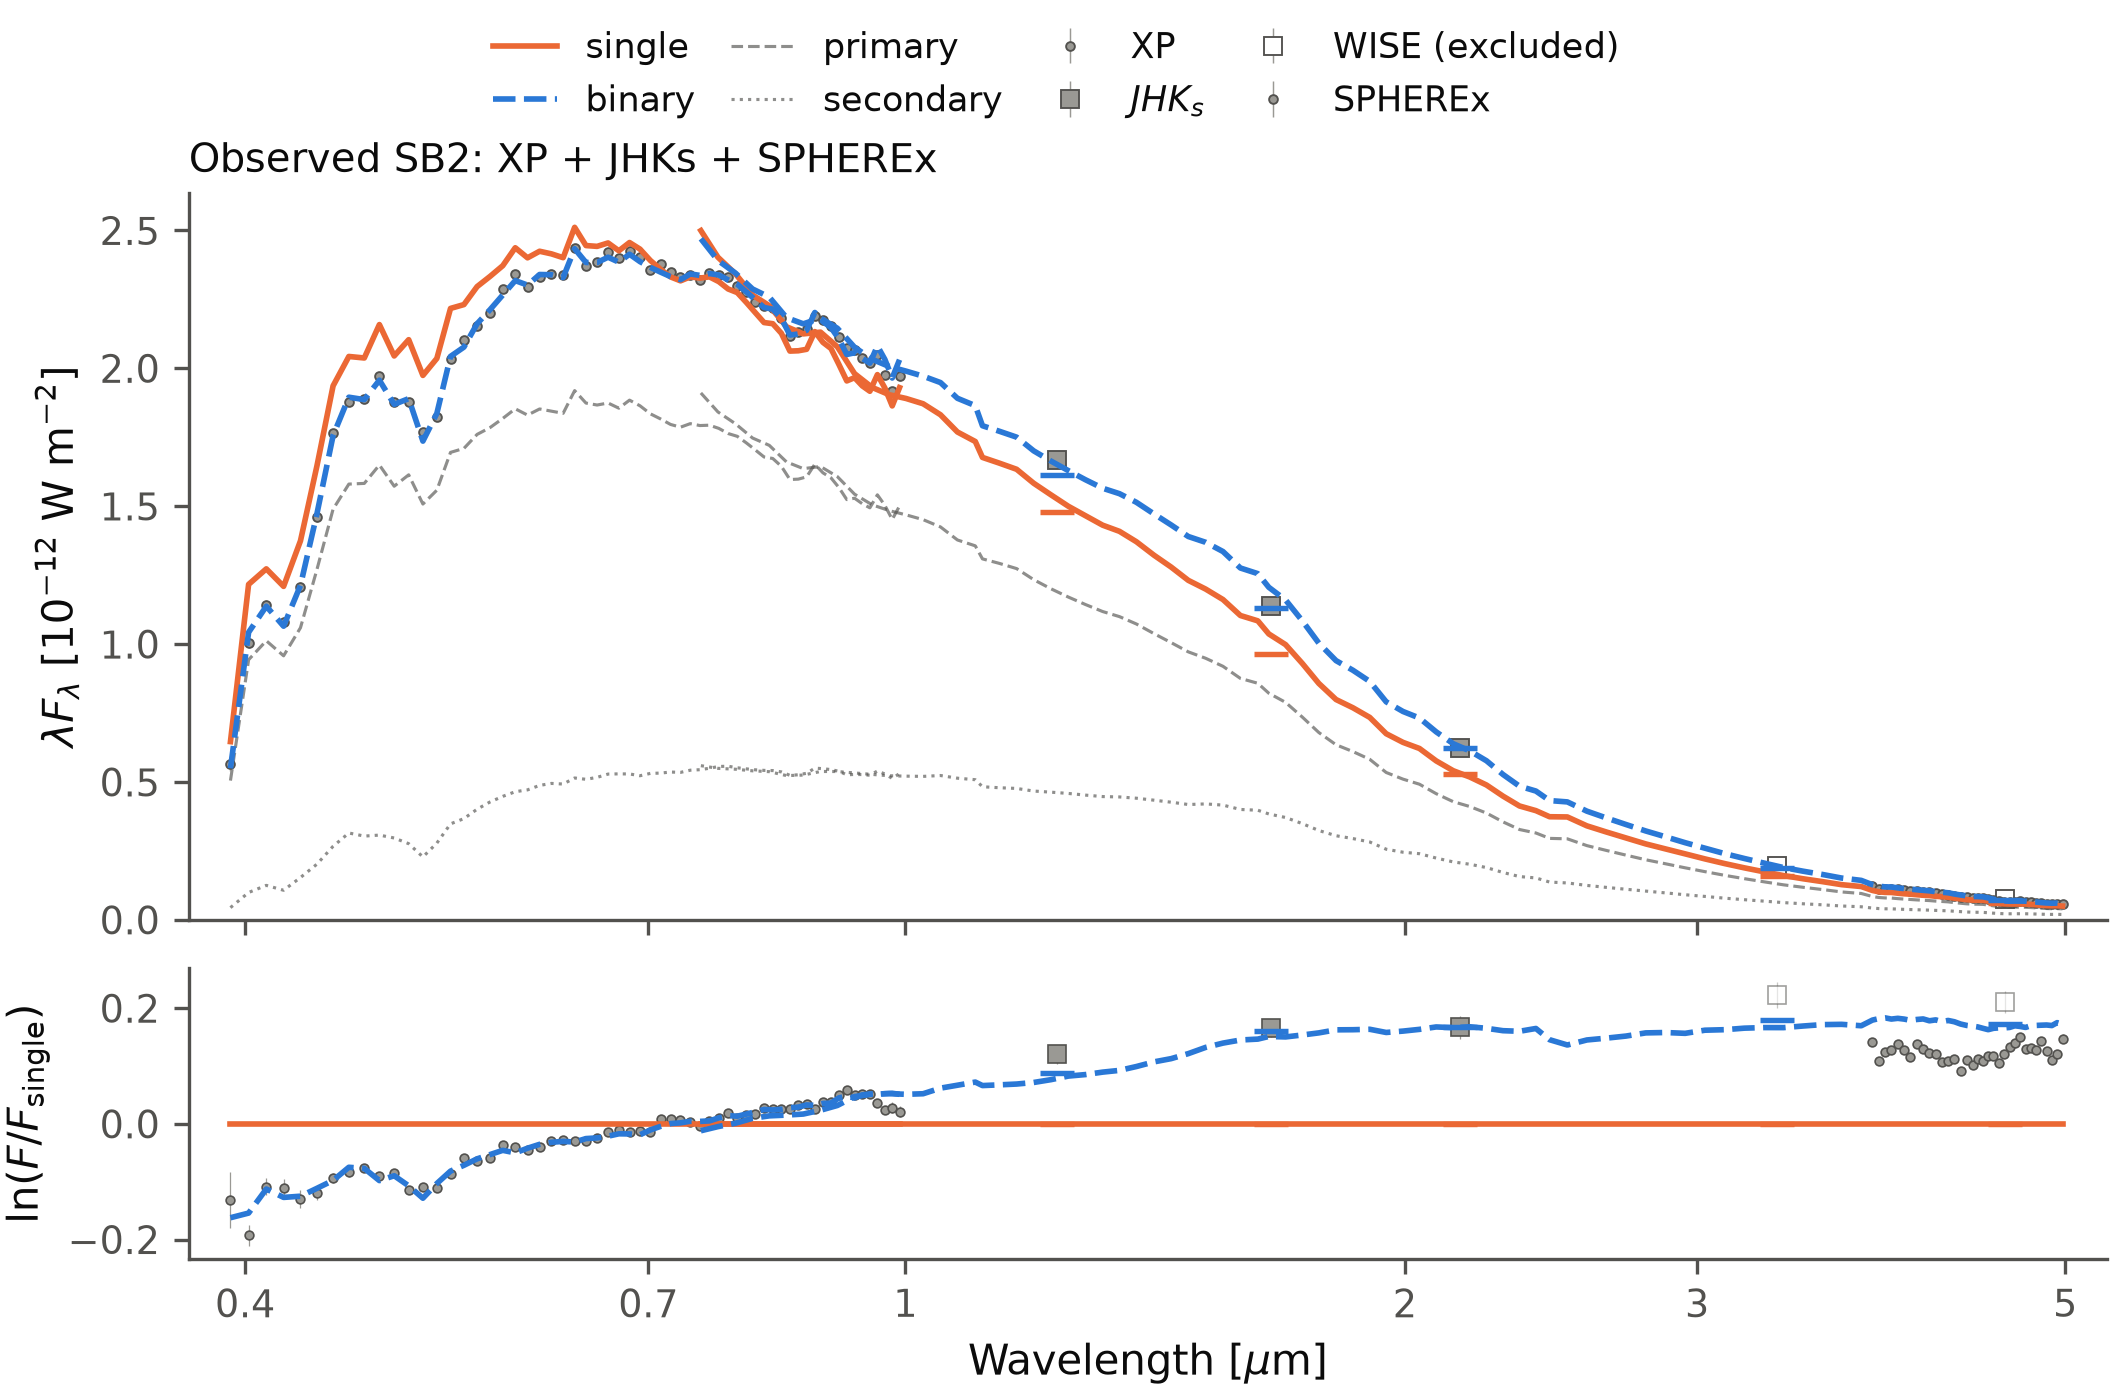

In [6]:
fig = plot(combined, sph_result, title='Observed SB2: XP + JHKs + SPHEREx',
           path=OUT / '02_fit.png')
fig.savefig(OUT / '02_fit.pdf', bbox_inches='tight', pad_inches=.02)
plt.close(fig)
display(Image(filename=str(OUT / '02_fit.png')))

## What this example tells us
SPHEREx adds 34 observed channels, but it does not automatically improve agreement
with the RV mass ratio: q changes from about 0.855 to 0.829, while q_RV is 0.868.
The fit retains the measurements and shows the mismatch. Age reaches 10 Gyr.

Aperture fluxes have no PSF encircled-energy correction; centering is fixed at the
propagated query epoch, with no per-exposure motion tracking or neighbour deblending.
This is a real acquisition and fitting demonstration, not a calibration validation.

**Discussion:** do the additional channels make this mass ratio more trustworthy?
Only if their extraction and the stellar predictions describe those channels adequately.

**Try after the talk:** compare a PSF extraction from XphereX, using `load_spherex(base,
path, method='psf')`, without changing its observed fluxes.

Extraction provenance and limits: [SPHEREx acquisition](../../docs/spherex.md).
Next: [connect the stellar model to orblet](03_orblet_joint_fit.ipynb).

Figure-generating code: [02_observed_spherex.py](02_observed_spherex.py).

In [7]:
# Optional PSF exercise; provide an existing XphereX PSF extraction.
RUN_PSF_COMPARISON = False
if RUN_PSF_COMPARISON:
    psf = load_spherex(base, Path('path/to/psf_spectrum.csv'), method='psf')
    psf_fit = fit(psf, kind='binary', model=model, age_gyr=None, feh=None)
    print(f"PSF q={psf_fit['q']:.4f}; aperture q={sph_result['binary']['q']:.4f}")